# Assignment 2 $-$ Argument Acquisition
_Solutions have to be submitted in pairs of two by Monday, May 11th, 23:59 (UTC+2)._

**Grading:**
- This assignment is worth 30 points, you get points for running code without unhandled, preventable errors, correct outputs and answers to analysis questions
- **0 - *Fail*:** No submission; non-working code (preventable errors and exceptions); code that directly contradicts the task description or produces incorrect outputs; authorship violations like plagiarism or solutions fully or largely generated by AI

**Submission Components:**

- **Code:** Tasks 1 and 2
  - **Output Files:** Your submission should include the output files in the correct folder with the correct naming.
  - **Explanation:** You should add overall explanations of your code (i.e., modify/employ docstrings) and comments for individual implementation decisions.
- **Analysis:** Task 3 answered in full text with sensible formatting and using the results from task 2 explicitly.


**Submission Group:**
Ole Rößler,
TODO

In [374]:
import bz2
import json 
import pandas as pd
import numpy as np
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

## Assignment Goals

### Motivation
To study arguments, we need arguments, which we can get from many places: comment sections (on news websites/social media), discussion or debate forums, deliberative democracy platforms, parliamentary proceedings (speeches, debates), talk shows ...

Acquiring and manually processing new data takes time and also often money, e.g., for manual annotation studies. Before collecting new data, it is thus usually worth checking what already exists and whether you are allowed to use it. Below is a simple workflow to finding data for any research project:

1. Check for existing datasets
    - Papers related to your topic (methods or goals)
    - Survey papers compiling datasets and resources on one topic
    - Platforms like Kaggle, HuggingfaceHub (datasets you find here often come with exact instructions and guides)
2. No luck? $\to$ Check usage restrictions
    - `robots.txt` files show bots which subpages (not) to crawl, below is an example from [kialo](https://kialo.com/robots.txt))
       ```
       User-agent: Googlebot
       Disallow:
       User-agent: *
       Disallow: /
       ```
    - API terms (e.g., [data API terms](https://redditinc.com/policies/data-api-terms))
3. If unsure, ask:
    - Check with the rights holders directly (e.g., contact form, email).
    - Never illicitly use data: you cannot publish your data/findings without academic/legal consequences, but most importantly, we do not want to exacerbate the problem of data hungry AI-companies using data that is private or copyrighted.

### Application

We now apply this to a common task in computational argumentation: **argument quality assessment**.

Process argumentative discussions scraped from [r/ChangeMyView](https://www.reddit.com/r/changemyview/) by [Tan et al. (2016)](https://doi.org/10.1145/2872427.2883081) into a dataset usable for the task. On the subreddit, people can post their genuine opinions (OPs) to be persuaded of the opposite. If they are persuaded, they award a $\Delta$ point to the persuasive comment.

In this assignment, you will create a new dataset suitable for training a model to perform the following task:

> **Persuasiveness Classification:** Given an argumentative text, predict its persuasiveness, i.e., if it was awarded a $\Delta$.
> 
> **Example:**
>
> Because of the fact that the Vice President is responsible for Presidential duties when the President is away means that they are the perfect person to take over for them. In the event of whatever emergency would surround the need for a VP to take the President's spot, the experience that the VP already has with their duties would mean they could easily step into the President's place without disrupting the rest of the cabinet, all of whom would likely be very busy with their current departments.
>
> $\Delta$
> 
> (OP Thread: *CMV: The position of Vice President of the United States should be eliminated from our government.*)

### Dataset Structure
The data was scraped from Reddit for [Tan et al. (2016)](https://doi.org/10.1145/2872427.2883081), thus, its format and encoded information directly match the output of the [Reddit API](https://redditinc.com/policies/data-api-terms). 

Start by exploring the data:

1. Visit the dataset's [homepage](https://chenhaot.com/papers/changemyview.html) to consult the Readme and Blog tutorial
2. Follow these instructions to extract the data from `cmv_reddit_api_data.jsonlist.bz2`, which is saved in `./data`.
3. Explore the data: what does an instance look like, which information is encoded, and how are comment threads stored?
   
Move on to the graded tasks once you are familiar with the dataset structure.

In [375]:
data_path = "data/cmv_reddit_api_data.jsonlist.bz2"


# DATA EXPLORATION OF DELTABOT COMMENTS
rows = []
with bz2.open(data_path, "rt") as f:
    for line in f:
        thread = json.loads(line)
        for c in thread["comments"]:
            rows.append({"author": c.get("author"), 
                         "text": c.get("body", "")})

df1 = pd.DataFrame(rows)

# Use regex to extract unique deltabot comment types
deltabot = df1[df1["author"].isin(["DeltaBot"])].copy()
deltabot["text"] = (deltabot["text"].fillna("").str.lower().str.strip())
starts = deltabot["text"].copy()
starts = starts.str.replace( r"/u/[a-z0-9_\-]+", "/u/<user>", regex=True)
starts = starts.str.extract(r"(^.*?\.)")[0]
print(starts.value_counts())

0
confirmed: 1 delta awarded to /u/<user>.                                                                              1817
this delta is currently disallowed as your comment contains either no or little text ([comment rule 4](http://www.     271
this award is currently disallowed as your comment doesn't include enough text ([comment rule 4](http://www.            68
you cannot award op a delta as the moderators feel that allowing so would send the wrong message.                       28
you cannot award op a delta as the moderators feel that allowing so would corrupt the delta system.                      7
you have already awarded /u/<user> a delta in this comment tree.                                                         3
Name: count, dtype: int64


In [376]:
def load_jsonl_bz2(filepath:str) -> list[dict]:
    with bz2.open(filepath, "rt") as f:
        return [json.loads(line) for line in f]

threads = load_jsonl_bz2(data_path)

---

## Task 1

Extract all the posts from all the original threads into one dataset and save it.
- You should only include the following information: _post\_id, parent\_id, thread\_id, author, text, impact_votes, impact_persuasion_, and _persuasiveness_.
    - The first five features are identically named in the data, but the _impact_ features use the upvotes and author flair, respectively, and should be saved as positive integers (_- 1 point each_).
    - The _persuasiveness_ must be extracted as a $\Delta$ in the comment's replies and saved as a binary score (0 or 1) (_- 3 points_).
- Add all comments to a `pandas.DataFrame` with column names _exactly_ matching the above list of features (_- 1 point per error_). 
- Make sure that you only include posts that are usable for prediction, i.e., posts with unique, non-empty text fields (_- 3 points_).
- Save the DataFrame to a cvs `./outputs/posts.csv` file _without_ including the index (_1 point_).

<div style="text-align: right"><b>10 points</b></div>

In [377]:
'''
Extract relevant comments from the thread and transform it into a dataframe
'''

required_comment_keys = {
    "body",
    "id",
    "link_id",
    "parent_id",
    "author",
    "ups",
    "author_flair_text"
}

all = []
non_op, deleted_cmt, unconfirmed_deltas,no_grandparent,op_is_grandparent, duplicate_cmt = 0,0,0,0,0, 0
for thread in threads:
    post = {}
    post["text"] = thread["selftext"]
    post["post_id"] = thread["name"]
    post["thread_id"] = thread["name"]
    post["parent_id"] = None
    post["author"] = thread["author"]
    post["impact_votes"] = thread["ups"]
    post["impact_persuasion"] = thread["author_flair_text"]
    post["persuasiveness"] = 0
    all.append(post)

    # Map IDs only for the current thread so we don't update posts/comments from prior threads
    thread_map = {post["post_id"]: len(all) - 1}

    for c in thread["comments"]:
        if not required_comment_keys.issubset(c):
            continue
        # All DeltaBot comments represent a rewarded delta
        if "DeltaBot" in c["author"]:
            # Check that DeltaBot award a delta
            if not "Confirmed: 1 delta awarded" in c["body"]:
                unconfirmed_deltas += 1
                continue

            # Delta awarded by non-op
            if all[thread_map[c["parent_id"]]]["author"] != thread["author"]:
                non_op += 1
                continue
            
            grandparent_id = all[thread_map[c["parent_id"]]]["parent_id"]
            
            # Ensure Grandparent exists
            if not grandparent_id:
                no_grandparent += 1
                continue
            
            # Ensure delta comment has text
            if all[thread_map[grandparent_id]]["text"] == "[deleted]" or all[thread_map[grandparent_id]]["text"] == None or all[thread_map[grandparent_id]]["text"] == "" :
                deleted_cmt +=1
                continue

            # Ensure Grandparent is not the OP
            if grandparent_id == thread["name"]: 
                op_is_grandparent += 1
                continue

            # Dublicate DeltaBot Messages
            if all[thread_map[grandparent_id]]["persuasiveness"] == 1:
                duplicate_cmt += 1
                continue
            
            all[thread_map[grandparent_id]]["persuasiveness"] = 1
            continue
            
        comment = {}
        comment["text"] = c["body"] 
        comment["post_id"] = c["name"]
        comment["thread_id"] = c["link_id"]
        comment["parent_id"] = c["parent_id"]
        comment["author"] = c["author"]
        comment["impact_votes"] = c["ups"]
        comment["impact_persuasion"] = c["author_flair_text"]
        comment["persuasiveness"] = 0

        all.append(comment)
        thread_map[comment["post_id"]] = len(all) - 1


df = pd.DataFrame(all)

#remove all duplicate comments
before_unique_pers_txt = len(df[df["persuasiveness"]==1])
df.drop_duplicates(subset=["text"], keep=False, inplace=True)
after_unique_pers_txt = len(df[df["persuasiveness"]==1])

# replace deleted authors with None
df.loc[df["author"] == "[deleted]", "author"] = None

# only include threads that have an original post (OP)
threads_with_op = set(df[(df['thread_id'] == df['post_id']) & df['parent_id'].isna()]['thread_id'])
df = df[df['thread_id'].isin(threads_with_op)]

# Iteratively remove dangling comments
before_dandling_pers = len(df[df["persuasiveness"]==1])
while True:
    mask = df["parent_id"].isin(df["post_id"]) | df["parent_id"].isna()
    if mask.all():
        break
    df = df[mask]
after_dandling_pers = len(df[df["persuasiveness"]==1])

print("Filtering unessential delta bot comments")
print(f"Non OP rewarded delta: {non_op}-times")
print(f"Delta rewarded to deleted comments: {deleted_cmt}-times")
print(f"DeltaBot didnt reward a delta: {unconfirmed_deltas}-times")
print(f"Grandparent doesnt exist: {no_grandparent}-times")
print(f"OP rewarded delta to himself: {op_is_grandparent}-times")
print(f"Duplicate deltabot comments: {duplicate_cmt}-times")
print(f"Dublicate text from persuasive comments: {before_unique_pers_txt-after_unique_pers_txt}-times")
print(f"Parent ID doesnt exist anymore: {before_dandling_pers-after_dandling_pers}")

Filtering unessential delta bot comments
Non OP rewarded delta: 194-times
Delta rewarded to deleted comments: 14-times
DeltaBot didnt reward a delta: 377-times
Grandparent doesnt exist: 0-times
OP rewarded delta to himself: 0-times
Duplicate deltabot comments: 11-times
Dublicate text from persuasive comments: 2-times
Parent ID doesnt exist anymore: 13


In [378]:
'''
Transform columns to correct types
'''

df["text"] = df["text"].astype(str)
df["post_id"] = df["post_id"].astype(str)
df["thread_id"] = df["thread_id"].astype(str)
df["parent_id"] = df["parent_id"].astype(str)
df["author"] = df["author"].astype(str)

# replace negatives impact_votes with 0, and convert to int
df["impact_votes"] = df["impact_votes"].apply(lambda x: max(x, 0)).astype(int) 

# remove weird characters, impute missing values with 0, then convert to int
df["impact_persuasion"] = df["impact_persuasion"].apply(
    lambda x: str(x).replace("∆", "").replace("Δ", "").replace("âˆ†", "")
)
df["impact_persuasion"] = df["impact_persuasion"].replace("nan", 0).astype(int)

# convert persuasiveness to int
df["persuasiveness"] = df["persuasiveness"].astype(int)

In [379]:
# Same dataframe to csv 
df.to_csv("./outputs/posts.csv", index=False)
df

,text,post_id,thread_id,parent_id,author,impact_votes,impact_persuasion,persuasiveness
0,"From what I understand, the only significant d...",t3_3j90qv,t3_3j90qv,NaN,TentacleBird,0,1,0
1,The vice president often is called to act as a...,t1_cun9x23,t3_3j90qv,t3_3j90qv,draculabakula,1,14,0
2,"Your first point is very strong, however, noth...",t1_cunbngs,t3_3j90qv,t1_cun9x23,TentacleBird,1,1,0
3,Because of the fact that the Vice President is...,t1_cuncccq,t3_3j90qv,t1_cunbngs,EagenVegham,1,1,1
4,∆\n\nI realize now that the VP's duties can't ...,t1_cuncmdn,t3_3j90qv,t1_cuncccq,TentacleBird,1,1,0
...,...,...,...,...,...,...,...,...
145592,It's not my fault that I am fat. It is societi...,t1_cr3a8j2,t3_35bc4b,t1_cr34hz2,Cinnamon_Boots,0,0,0
145593,If you are so certain the economy will fail ca...,t1_cr2uooe,t3_35bc4b,t3_35bc4b,NorbitGorbit,0,8,0
145594,I was asking a question seeking advice for a v...,t1_cr2wwo2,t3_35bc4b,t1_cr2uooe,WumboWombo,2,0,0
145595,my genuine constructive advice is to make a be...,t1_cr4nqry,t3_35bc4b,t1_cr2wwo2,NorbitGorbit,1,8,0


---

## Task 2 $-$ Data Exploration

Now that we have the data, we can analyze discussion and interaction patterns with regards to persuasiveness. For this, we first need to calculate relevant metrics and statistics. In the following task, you will calculate different data statistics from your extracted DataFrame and then display them in a sensible way.

### 2.1 Persuasion Patterns
First we want to find patterns in persuasion behavior. For this we will divide the threads into successful from unsuccessful persuasion attempts based on the occurrence of $\Delta$'s in the threads. Then, we can compare user behavior between these two sets.

1. What is the ratio of threads with at least one $\Delta$-awarded comment? (_1 point_)
2. What is the average number of the original poster's (OP) responses and its standard deviation? (_1 point_)
3. What is the average number of distinct users in a thread and its standard deviation? (_1 point_)

As the exact number of these metrics may be important to find patterns, a table visualization is superior to a plot in this case. Please add the thread ratio and averages (not the standard deviation) to a table with columns _persuasive_ and _non-persuasive_, and with row indices _ratio_, _OP responses_, and _distinct users_. Use the `DataFrame.to_markdown()` method to build the table and round floats to three decimal points (_2 points_). No formatting/rounding should be done to the data beforehand.

### 2.2 Persuasion Effort
For the next two metrics, use only those threads with at least one $\Delta$, i.e., those in the _persuasive_ set above. Calculate how long it takes until a $\Delta$ point is awarded in a given thread. Calculate this persuasion effort in two ways: 

1. What is the distribution and average depth of the $\Delta$-awarded comments? The depth is the number of parent comments to reach from the answer to the OP.
2. How often does the $\Delta$-awarded _user_ post (overall and on average) in the corresponding thread? If multiple users in the same thread were awarded $\Delta$ points, treat each _\<user>-\<thread>_ pair as its own instance to count answers. 
3. What are the average impact ratings of a $\Delta$-awarded comment/user and its standard deviation? If multiple users in the same thread were awarded $\Delta$ points, treat each _\<user>-\<thread>_ pair as its own instance to count answers. 

Calculate all statistics (_3 points_) and plot the first two results in aligned subfigures (_2 points_). Each figure should show a histogram of the $\Delta$ depth/user comment count and further include the average depth/count as an additional line in the plot. The plots should have titles, as well as axis descriptions. For question 3, calculate the statistics and keep them for the next task. 


<div style="text-align: right"><b>10 points</b></div>

In [380]:
# Identify successful threads (at least one delta-awarded comment)
threads = (df.groupby("thread_id")["persuasiveness"].sum() > 0)
successful_thread_ids = threads[threads].index

# Split threads into successful and unsuccessful persuasion attempts
df_successful = df[df["thread_id"].isin(successful_thread_ids)]
df_unsuccessful = df[~df["thread_id"].isin(successful_thread_ids)]

In [381]:
"2.1.1 Ratio of of threads with at least one delta"
s_ratio = len(successful_thread_ids) / len(threads)
u_ratio =  (len(threads) - len(successful_thread_ids)) / len(threads)

print(f"{len(successful_thread_ids)} of {len(threads)} were persuasive (e.g. a gamma was rewarded).")
print(f"Therefore {s_ratio*100:.2f}% of the threads were successful\n")

print(f"{len(threads) - len(successful_thread_ids)} of {len(threads)} were non persuasive (e.g. no gamma was rewarded).")
print(f"Therefore {u_ratio*100:.2f}% of the threads were unsuccessful")

976 of 2254 were persuasive (e.g. a gamma was rewarded).
Therefore 43.30% of the threads were successful

1278 of 2254 were non persuasive (e.g. no gamma was rewarded).
Therefore 56.70% of the threads were unsuccessful


In [382]:
"2.1.2 Average number of OP's responses"
def get_op_responses_statistics(df):
    op_rsps = []

    #get the number of responses from the op per thread
    for t_id,_ in df.groupby("thread_id"):
        thread_comments = df[df["thread_id"] == t_id]
        #get thread op
        op_author = thread_comments[thread_comments["parent_id"].isna()]["author"].iloc[0]
        #count thread comment authors
        author_counts = Counter([d["author"] for _,d in thread_comments.iterrows()])

        op_rsps.append(author_counts[op_author]-1) # exclude the OP (only responses)

    return op_rsps, np.average(op_rsps), np.std(op_rsps)

# Get op responses in successful threads
s_op_rsps, s_avg_op_rsps, s_op_rsp_std = get_op_responses_statistics(df_successful)
print(f"Average number of OP responses in conversations where a delta was awarded: {s_avg_op_rsps:.3f}")
print(f"Standard diviation of number of OP responses in conversations where a delta was awarded: {s_op_rsp_std:.3f}\n")

# Get op responses in unsuccessful threads
u_op_rsps, u_avg_op_rsps, u_op_rsp_std = get_op_responses_statistics(df_unsuccessful)
print(f"Average number of OP responses in conversations where no delta was awarded: {u_avg_op_rsps:.3f}")
print(f"Standard diviation of number of OP responses in conversations where no delta was awarded: {u_op_rsp_std:.3f}\n")

Average number of OP responses in conversations where a delta was awarded: 11.745
Standard diviation of number of OP responses in conversations where a delta was awarded: 10.365

Average number of OP responses in conversations where no delta was awarded: 10.431
Standard diviation of number of OP responses in conversations where no delta was awarded: 11.216



In [383]:
if DEBUG:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Left plot
    sns.histplot(
        s_op_rsps,
        kde=True,
        ax=axes[0],
    )
    axes[0].set_title("Successful Discussions")
    axes[0].set_xlabel("Number of OP Responses")
    axes[0].set_ylabel("Count")

    # Right plot
    sns.histplot(
        u_op_rsps,
        kde=True,
        ax=axes[1],
    )
    axes[1].set_title("Unsuccessful Discussions")
    axes[1].set_xlabel("Number of OP Responses")

    # Overall title
    fig.suptitle("Distribution of OP Responses")

    fig.tight_layout()
    plt.show()

In [384]:
"2.1.3 Average number of distinct users in a thread"


def users_in_thread_statistics(df):
    number_of_usrs = []
    #get the number of responses from the op per thread
    for t_id,_ in df.groupby("thread_id"):
        thread_comments = df[df["thread_id"] == t_id]
        destinct_authors = set([d["author"] for _,d in thread_comments.iterrows()])
        number_of_usrs.append(len(destinct_authors))

    return number_of_usrs, np.average(number_of_usrs), np.std(number_of_usrs)

s_users, s_avg_users, s_users_std = users_in_thread_statistics(df_successful)
print(f"Average number of distinct users in a successful thread: {s_avg_users:.3f}")
print(f"Standard diviation of distinct users in a successful thread: {s_users_std:.3f}\n")

u_users, u_avg_users,u_users_std = users_in_thread_statistics(df_unsuccessful)
print(f"Average number of distinct users in a unsuccessful thread: {u_avg_users:.3f}")
print(f"Standard diviation of distinct users in an unsuccessful thread: {u_users_std:.3f}")

Average number of distinct users in a successful thread: 27.877
Standard diviation of distinct users in a successful thread: 38.957

Average number of distinct users in a unsuccessful thread: 23.006
Standard diviation of distinct users in an unsuccessful thread: 28.257


In [385]:
if DEBUG:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Left plot
    sns.histplot(
        s_users,
        kde=True,
        ax=axes[0],
    )
    axes[0].set_title("Successful Discussions")
    axes[0].set_xlabel("Number of Distinct Users")
    axes[0].set_ylabel("Count")

    # Right plot
    sns.histplot(
        u_users,
        kde=True,
        ax=axes[1],
    )
    axes[1].set_title("Unsuccessful Discussions")
    axes[1].set_xlabel("Number of Distinct Users")

    # Overall title
    fig.suptitle("Distribution of Distinct Users in a Thread")

    fig.tight_layout()
    plt.show()

In [386]:
"""Summary of 2.1.1 - 2.1.3"""

metrics = {
    "persuasive": [s_ratio, s_avg_op_rsps, s_avg_users],
    "non-persuasive": [u_ratio, u_avg_op_rsps, u_avg_users],
}

index = ["ratio", "OP responses", "distinct users"]

# Create DataFrame
summary = pd.DataFrame(metrics, index=index)

print(summary.to_markdown(floatfmt=".3f"))

|                |   persuasive |   non-persuasive |
|:---------------|-------------:|-----------------:|
| ratio          |        0.433 |            0.567 |
| OP responses   |       11.745 |           10.431 |
| distinct users |       27.877 |           23.006 |


In [387]:
"""2.2.1: Depth of delta awarded comments (in successful threads)"""

depths = []
for t_id in successful_thread_ids:
    thread_comments = df_successful[df_successful["thread_id"] == t_id]
    delta_comments = thread_comments[thread_comments["persuasiveness"] == 1]
    for _,c in delta_comments.iterrows():        
        depth = 0
        parent = c["parent_id"]
        while parent:
            parent_row = thread_comments[thread_comments["post_id"] == parent]
            if parent_row.empty:
                break
            parent = parent_row.iloc[0]["parent_id"]
            depth += 1
        depths.append(depth - 1)  # Subtract 1 to count direct replies to the original post as depth 0

# Average over all deltas to get the average depth of awarded deltas
avg_depth = np.average(depths)
std_depth = np.std(depths)
overall_depths = depths

print(f"The average depth of a comment, that was awarded a delta is (in a successful thread): {avg_depth:.3f}")
print(f"Standard diviation of depth of a persuasive comment (in a successful thread): {std_depth:.3f}\n")

The average depth of a comment, that was awarded a delta is (in a successful thread): 1.236
Standard diviation of depth of a persuasive comment (in a successful thread): 1.734



In [388]:
"""2.2.2: Number of comments from delta awarded author (in successful threads)"""

number_comments = []
for thread_id in successful_thread_ids:
    thread_comments = df_successful[df_successful["thread_id"] == thread_id]
    delta_comments = thread_comments[thread_comments["persuasiveness"] == 1]

    comments_per_delta_author = [
        int(((thread_comments["author"] == d["author"]) & thread_comments["author"].notna()).sum()) or 1 for _, d in delta_comments.iterrows()
    ]

    number_comments.extend(comments_per_delta_author)    
    
agv_delta_author_comments = np.average(number_comments)
std_delta_author_comments = np.std(number_comments)
overall_delta_author_comments = number_comments

print(f"The average number of comments of a delta awarded author (in a successful thread): {agv_delta_author_comments:.3f}")
print(f"Standard diviation of the number of comments from a delta awarded author (in a successful thread): {std_delta_author_comments:.3f}\n")

The average number of comments of a delta awarded author (in a successful thread): 2.805
Standard diviation of the number of comments from a delta awarded author (in a successful thread): 2.870



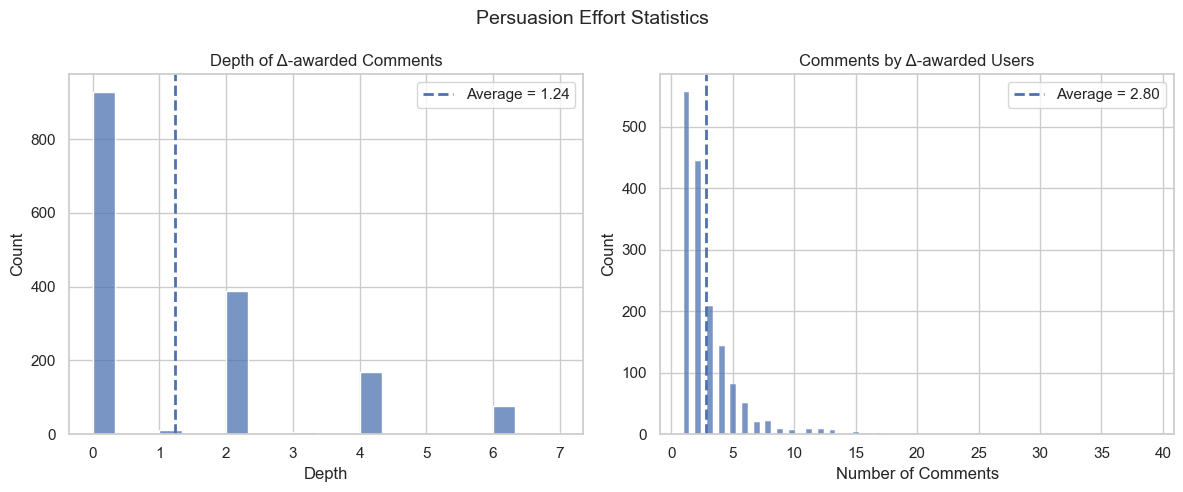

In [389]:
'''Plots for 2.2.1/2.2.2'''

fig, axes = fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot
sns.histplot(
    overall_depths,
    ax=axes[0]
)

axes[0].axvline(
    avg_depth,
    linestyle="--",
    linewidth=2,
    label=f"Average = {avg_depth:.2f}"
)

axes[0].set_title("Depth of Δ-awarded Comments")
axes[0].set_xlabel("Depth")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right plot
sns.histplot(
    overall_delta_author_comments,
    ax=axes[1]
)
axes[1].axvline(
    agv_delta_author_comments,
    linestyle="--",
    linewidth=2,
    label=f"Average = {agv_delta_author_comments:.2f}"
)

axes[1].set_title("Comments by Δ-awarded Users")
axes[1].set_xlabel("Number of Comments")
axes[1].set_ylabel("Count")
axes[1].legend()

fig.suptitle("Persuasion Effort Statistics", fontsize=14)

fig.tight_layout()
plt.show()

In [390]:
"""2.2.3: Impact rating of delta-awarded comments (in successful threads)"""

imp_pers_ratings,imp_votes_ratings  = [],[]
for thread_id in successful_thread_ids:
    thread_comments = df_successful[df_successful["thread_id"] == thread_id]
    delta_comments = thread_comments[thread_comments["persuasiveness"] == 1]

    imp_pers = [d["impact_persuasion"] for _,d in delta_comments.iterrows()]
    
    imp_votes = [d["impact_votes"] for _,d in delta_comments.iterrows()]

    imp_pers_ratings.extend(imp_pers)    
    imp_votes_ratings.extend(imp_votes)    

agv_impact_pers = np.average(imp_pers_ratings)
std_impact_pers = np.std(imp_pers_ratings)

agv_impact_votes = np.average(imp_votes_ratings)
std_impact_votes = np.std(imp_votes_ratings)


print(f"The average impact persuasion of delta awarded comments (in successful threads): {agv_impact_pers:.3f}")
print(f"Standard diviation of the impact persuasion of delta awarded comments (in successful threads): {std_impact_pers:.3f}\n")
print(f"The average impact votes of delta awarded comments (in successful threads): {agv_impact_votes:.3f}")
print(f"Standard diviation of the votes ratings of delta awarded comments (in successful threads): {std_impact_votes:.3f}")

The average impact persuasion of delta awarded comments (in successful threads): 15.852
Standard diviation of the impact persuasion of delta awarded comments (in successful threads): 29.048

The average impact votes of delta awarded comments (in successful threads): 18.806
Standard diviation of the votes ratings of delta awarded comments (in successful threads): 64.991


---

## Task 3 $-$ Data Analysis
As we now have metrics to base our analysis and interpretation of data patterns on, we can explore the dataset fully. For both subtasks of task 2, analyze and interpret your observations (_5 points each_). For this, you should adhere to the argument structure below:
1. **Claim** $-$ Verbalize and summarize the overall findings from the subtask (*2 points*).
2. **Evidence** $-$ Include specific numbers from task 2. Copy the markdown table from 2.1 into your answer here (*1 point*).
3. **Interpretation** $-$ Reason about why this observation might be happening and what it may mean about persuasive behavior (*2 points*).

<div style="text-align: right"><b>10 points</b></div>

### Analysis 2.1

#### Claim
A higher number of distinct users are a stronger indicator of persuasion and OP engagement does not reflect on the nature of the thread (persuasiveness).

#### Evidence

|                |   persuasive |   non-persuasive |
|:---------------|-------------:|-----------------:|
| ratio          |        0.433 |            0.567 |
| OP responses   |       11.745 |           10.431 |
| distinct users |       27.877 |           23.006 |

#### Interpretation
The biggest gap in the table is in distinct users: persuasive threads have on average about 27.9 unique commenters, compared to  23.0 in non-persuasive threads. The number of distinct users is a stronger indicator of persuasion, because different people add diverse opinions.

It looks like OP's engagement doesn't change the outcome of a thread. This could be, because an OP who replies may be doing one of two very different things: 
He could on the on hand be weighing new arguments, or he could stubbornly defending their original view. Those two behaviors point in opposite directions, so they might cancel each other out.
<!-- It looks like OP's engagement doesn't change the outcome of a thread, BUT there are also more unique users in persuasive threads and that's could be the reason why there are more OP responses in those threads. Therefore persuasive threads have more OP engagement.-->


---


### Analysis 2.2

#### Claim
Most successful persuasion happens relatively early in the discussion, but persuasive users usually participate multiple times before receiving a Delta.
#### Evidence

- **Average depth of a delta comment:** 1.236
- **Standard diviation of depth of a persuasive comment**: 1.734
- **Average number of comments of a delta awarded author:** 2.805
- **Average impact persuasion of delta awarded comments:** 15.852
- **Standard diviation of the impact persuasion of delta awarded comments:** 29.048
- **Average impact votes of delta awarded comments:** 18.806
- **Standard diviation of the votes ratings of delta awarded comments:** 64.991
- **Oscillating depth of $\Delta$-awarded comments:** see graph "Persuasion Effort Statistics" (left subplot)

#### Interpretation
The low average depth suggests that persuasion often happens early in the discussion. Many OPs may already be open to changing their opinion (they posted on r/changemyview), so a strong argument near the start can be enough to earn a Delta, but a higher standard deviation suggests that fit could also take longer to persuade OP in some cases.

At the same time, persuasive users usually post more than once in the thread. This suggests, despite most persuasions happening directly, persuasion often involves follow-up explanations and continued engagement rather than a single reply.

The large standard deviation in user activity shows that persuasion behavior varies a lot. Some OPs are convinced quickly, while others require longer explanations. This is also reflected in the "depth of delta-awarded comments" graph, as the likelyhood of a persuasion happening is way higher on even depths. This indicates a back-and-forth between the OP and a commenter (where the OP responds on odd depths).

The average impact persuasion score suggests that experienced users may be better at presenting arguments clearly and engaging effectively in discussion, however low experience users also persuade the OP sometimes.

An average user usually agrees with the persuading comment, but the distribution is still very broad (high standard deviation). This shows that not everyone is convinced by the argument which convinces the OP.